# GIBridge Stage 1 -- Primary/Correction Architecture

**Why this shape.** Standalone modality signal (measured on the ANOVA-selected features,
same split): mRNA 95.43%, Methylation 92.24%, Mutation 60.73%, CNV 45.21%. Two modalities
carry the signal, two are close to chance. A symmetric 4-way fusion (concat / static-weight
/ attention -- all tried already) made the model treat all four as equal partners, which is
why all three tied the mRNA-alone baseline instead of beating it.

**Architecture:** a primary branch (mRNA + Methylation) makes the main prediction; a
correction branch (CNV + Mutation) is blended in through a **per-class learnable gate**,
so the model can decide, class by class, whether the weak modalities are worth listening
to -- instead of one global on/off switch for the whole model.

```
primary_logits    = head( encode(mRNA)  concat encode(Methylation) )
correction_logits = head( encode(CNV)   concat encode(Mutation)    )
final_logits       = primary_logits + sigmoid(lambda_c) * correction_logits    (lambda_c: one learnable scalar per class)
```

Figures follow the same convention as the OncoBridge manuscript figures: Okabe-Ito palette,
300 DPI, PNG + PDF, light horizontal gridlines only, no 3D effects.

**Not executed in this environment** -- validated for shapes/gradients/device placement on
synthetic data before delivery; needs your GPU and real data for real numbers.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MaxAbsScaler
from sklearn.feature_selection import f_classif, SelectKBest, VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score, f1_score,
                              matthews_corrcoef, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import copy, time, json, random, warnings, gc
warnings.filterwarnings('ignore')

# -- figure style: matches the OncoBridge manuscript conventions --------------
mpl.rcParams['font.family'] = 'DejaVu Sans'       # falls back cleanly if Arial is unavailable
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.titlesize'] = 11
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelsize'] = 10
mpl.rcParams['xtick.labelsize'] = 9
mpl.rcParams['ytick.labelsize'] = 9
mpl.rcParams['legend.fontsize'] = 9
mpl.rcParams['figure.dpi'] = 130                  # on-screen preview only; saved figures use 300
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.grid.axis'] = 'y'              # light horizontal gridlines only
mpl.rcParams['grid.alpha'] = 0.30
mpl.rcParams['axes.axisbelow'] = True

VIRIDIS = plt.get_cmap('viridis')

def viridis_colors(n, low=0.15, high=0.95):
    '''n evenly-spaced colors from a truncated viridis (avoids the near-black low
    end) -- matches the OncoBridge Stage 2 figure convention, used here for every
    figure so the two papers stay visually consistent.'''
    if n == 1:
        return [VIRIDIS(high)]
    return [VIRIDIS(low + (high - low) * i / (n - 1)) for i in range(n)]

BASELINE_GREY = '#888888'  # reference lines / gridlines only, never used for data bars
SINGLE_COL, DOUBLE_COL = (3.5, 3.0), (7.0, 3.4)   # inches, matches single/double manuscript column widths

def section(title):
    print('\n' + '=' * 70)
    print(f'  {title}')
    print('=' * 70)

def save_fig(fig, name, checkpoint_dir):
    '''Saves a figure as both 300 DPI PNG and vector PDF -- the pair the manuscript
    toolchain expects, so figures never need re-exporting later.'''
    fig.savefig(f'{checkpoint_dir}{name}.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'{checkpoint_dir}{name}.pdf', bbox_inches='tight')

CONFIG = {
    'mrna_path'  : '/kaggle/input/datasets/proutkarshtiwari/gi-stage-1-analy-v2/mrna_gi.parquet',
    'cnv_path'   : '/kaggle/input/datasets/proutkarshtiwari/gi-stage-1-analy-v2/cnv_gi.parquet',
    'mut_path'   : '/kaggle/input/datasets/proutkarshtiwari/gi-stage-1-analy-v2/mut_gi.parquet',
    'meth_path'  : '/kaggle/input/datasets/proutkarshtiwari/gi-stage-1-analy-v2/meth_gi.parquet',
    'label_path' : '/kaggle/input/datasets/proutkarshtiwari/gi-stage-1-analy-v2/labels_gi.parquet',
    'label_col'  : '_gi_class',

    'select_k'    : {'mrna': 2000, 'cnv': 300, 'mut': 300, 'meth': 2000},
    'scaler_type' : {'mrna': 'standard', 'cnv': 'maxabs', 'mut': 'none', 'meth': 'none'},

    'embed_dim'  : 32,
    'hidden_dim' : 64,
    'dropout'    : 0.30,

    'label_smoothing_epsilon': 0.05,
    'related_weight': 0.6,
    'related_pairs': [
        ('cholangiocarcinoma', 'liver hepatocellular carcinoma'),
        ('esophageal carcinoma', 'stomach adenocarcinoma'),
    ],

    'main_epochs'  : 150,
    'main_patience': 20,
    'batch_size'   : 32,
    'lr'           : 3e-4,
    'weight_decay' : 1e-4,
    'clip_grad'    : 1.0,
    'max_class_weight': 8.0,

    'split_seed' : 42,
    'seeds'      : [42, 7, 123],

    'checkpoint_dir': '/kaggle/working/',
}

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(CONFIG['split_seed'])
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')  # pinned to a single GPU --
# this model is small enough that DataParallel overhead across 2 GPUs can be slower than 1
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
print(f'Device: {DEVICE}')

  GPU: Tesla T4
Device: cuda:0


In [2]:
section('Data loading')

t0 = time.time()
mrna_df  = pd.read_parquet(CONFIG['mrna_path'])
cnv_df   = pd.read_parquet(CONFIG['cnv_path'])
mut_df   = pd.read_parquet(CONFIG['mut_path'])
meth_df  = pd.read_parquet(CONFIG['meth_path'])
label_df = pd.read_parquet(CONFIG['label_path'])
print(f'Loaded 5 parquet files in {time.time()-t0:.1f}s')

assert (mrna_df.index == label_df.index).all()
assert (cnv_df.index  == label_df.index).all()
assert (mut_df.index  == label_df.index).all()
assert (meth_df.index == label_df.index).all()
print('Patient index alignment: OK')

le = LabelEncoder()
y_all = le.fit_transform(label_df[CONFIG['label_col']].values)
num_classes = len(le.classes_)
print(f'Classes ({num_classes}): {list(le.classes_)}')
print(label_df[CONFIG["label_col"]].value_counts().to_string())

gene_names_all = {'mrna': mrna_df.columns.tolist(), 'cnv': cnv_df.columns.tolist(),
                   'mut': mut_df.columns.tolist(), 'meth': meth_df.columns.tolist()}
X_all = {'mrna': mrna_df.values.astype(np.float32), 'cnv': cnv_df.values.astype(np.float32),
         'mut': mut_df.values.astype(np.float32), 'meth': meth_df.values.astype(np.float32)}
del mrna_df, cnv_df, mut_df, meth_df
gc.collect()


  Data loading
Loaded 5 parquet files in 6.6s
Patient index alignment: OK
Classes (6): ['cholangiocarcinoma', 'colorectal cancer', 'esophageal carcinoma', 'liver hepatocellular carcinoma', 'pancreatic adenocarcinoma', 'stomach adenocarcinoma']
_gi_class
stomach adenocarcinoma            367
colorectal cancer                 357
liver hepatocellular carcinoma    348
esophageal carcinoma              181
pancreatic adenocarcinoma         168
cholangiocarcinoma                 36


0

In [3]:
section('Stratified split (70/15/15)')

idx = np.arange(len(y_all))
tr_idx, tmp = train_test_split(idx, test_size=0.30, stratify=y_all, random_state=CONFIG['split_seed'])
vl_idx, te_idx = train_test_split(tmp, test_size=0.50, stratify=y_all[tmp], random_state=CONFIG['split_seed'])
print(f'Train={len(tr_idx)} | Val={len(vl_idx)} | Test={len(te_idx)}')


  Stratified split (70/15/15)
Train=1019 | Val=219 | Test=219


In [4]:
section('Feature selection: ANOVA F-test (train fold only) + modality-appropriate scaling')

def select_and_scale_anova(X_full, gene_names_full, tr_idx, vl_idx, te_idx, y_train, k, scaler_type, tag):
    X_tr_raw, X_vl_raw, X_te_raw = X_full[tr_idx], X_full[vl_idx], X_full[te_idx]
    vt = VarianceThreshold(threshold=0.0)
    vt.fit(X_tr_raw)
    keep_mask = vt.get_support()
    X_tr_v, X_vl_v, X_te_v = X_tr_raw[:, keep_mask], X_vl_raw[:, keep_mask], X_te_raw[:, keep_mask]
    kept_names = [n for n, keep in zip(gene_names_full, keep_mask) if keep]

    k_eff = min(k, X_tr_v.shape[1])
    selector = SelectKBest(score_func=f_classif, k=k_eff)
    selector.fit(X_tr_v, y_train)
    sel_mask = selector.get_support()
    selected_names = [n for n, s in zip(kept_names, sel_mask) if s]
    X_tr_s, X_vl_s, X_te_s = X_tr_v[:, sel_mask], X_vl_v[:, sel_mask], X_te_v[:, sel_mask]

    if scaler_type == 'standard':
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr_s).astype(np.float32)
        X_vl_s = sc.transform(X_vl_s).astype(np.float32)
        X_te_s = sc.transform(X_te_s).astype(np.float32)
    elif scaler_type == 'maxabs':
        sc = MaxAbsScaler()
        X_tr_s = sc.fit_transform(X_tr_s).astype(np.float32)
        X_vl_s = sc.transform(X_vl_s).astype(np.float32)
        X_te_s = sc.transform(X_te_s).astype(np.float32)
    else:
        sc = None
        X_tr_s, X_vl_s, X_te_s = X_tr_s.astype(np.float32), X_vl_s.astype(np.float32), X_te_s.astype(np.float32)

    print(f'  [{tag:4s}] ANOVA top-{k_eff:<4} | scaler={scaler_type}')
    return X_tr_s, X_vl_s, X_te_s, sc, selected_names, k_eff

Xp, fitted_scalers, selected_genes, gene_k = {}, {}, {}, {}
for mod in ['mrna', 'cnv', 'mut', 'meth']:
    tr, vl, te, sc, gnames, k_eff = select_and_scale_anova(
        X_all[mod], gene_names_all[mod], tr_idx, vl_idx, te_idx, y_all[tr_idx],
        k=CONFIG['select_k'][mod], scaler_type=CONFIG['scaler_type'][mod], tag=mod)
    Xp[mod] = (tr, vl, te)
    fitted_scalers[mod] = sc
    selected_genes[mod] = gnames
    gene_k[mod] = k_eff

CONFIG['gene_counts'] = gene_k
print(f'\nSelected feature counts: {gene_k} | total={sum(gene_k.values()):,}')

del X_all
gc.collect()

cw = compute_class_weight('balanced', classes=np.unique(y_all[tr_idx]), y=y_all[tr_idx])
cw = np.clip(cw, None, CONFIG['max_class_weight'])
cw_tensor = torch.FloatTensor(cw).to(DEVICE)
print(f'Class weights: {cw.min():.3f} - {cw.max():.3f} (heaviest: {le.classes_[np.argmax(cw)]})')

import joblib
for mod in ['mrna', 'cnv', 'mut', 'meth']:
    with open(f'{CONFIG["checkpoint_dir"]}gibridge_genes_{mod}.json', 'w') as f:
        json.dump(selected_genes[mod], f)
joblib.dump(fitted_scalers['mrna'], f'{CONFIG["checkpoint_dir"]}gibridge_scaler_mrna.pkl')
joblib.dump(fitted_scalers['cnv'],  f'{CONFIG["checkpoint_dir"]}gibridge_scaler_cnv.pkl')
with open(f'{CONFIG["checkpoint_dir"]}gibridge_label_classes.json', 'w') as f:
    json.dump(list(le.classes_), f)


  Feature selection: ANOVA F-test (train fold only) + modality-appropriate scaling
  [mrna] ANOVA top-2000 | scaler=standard
  [cnv ] ANOVA top-300  | scaler=maxabs
  [mut ] ANOVA top-300  | scaler=none
  [meth] ANOVA top-2000 | scaler=none

Selected feature counts: {'mrna': 2000, 'cnv': 300, 'mut': 300, 'meth': 2000} | total=4,600
Class weights: 0.661 - 6.793 (heaviest: cholangiocarcinoma)


In [5]:
section('Classical baselines (on the same ANOVA-selected, concatenated features)')

Xc_tr = np.concatenate([Xp[m][0] for m in ['mrna', 'cnv', 'mut', 'meth']], axis=1)
Xc_vl = np.concatenate([Xp[m][1] for m in ['mrna', 'cnv', 'mut', 'meth']], axis=1)
Xc_te = np.concatenate([Xp[m][2] for m in ['mrna', 'cnv', 'mut', 'meth']], axis=1)
yc_tr, yc_vl, yc_te = y_all[tr_idx], y_all[vl_idx], y_all[te_idx]

modality_alone_results = {}
for m in ['mrna', 'cnv', 'mut', 'meth']:
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
    clf.fit(Xp[m][0], yc_tr)
    m_preds = clf.predict(Xp[m][2])
    modality_alone_results[m] = {
        'acc': (m_preds == yc_te).mean() * 100,
        'macro_f1': f1_score(yc_te, m_preds, average='macro'),
        'mcc': matthews_corrcoef(yc_te, m_preds)}
    r = modality_alone_results[m]
    print(f'  [{m:<5}] acc={r["acc"]:5.2f}% | macro-F1={r["macro_f1"]:.4f} | MCC={r["mcc"]:.4f}')

baseline_results = {}

lr_clf = LogisticRegression(max_iter=3000, class_weight='balanced', C=1.0)
lr_clf.fit(Xc_tr, yc_tr)
lr_probs = lr_clf.predict_proba(Xc_te)
lr_preds = lr_probs.argmax(1)
baseline_results['Logistic Regression'] = {'acc': (lr_preds == yc_te).mean() * 100,
    'macro_f1': f1_score(yc_te, lr_preds, average='macro'), 'mcc': matthews_corrcoef(yc_te, lr_preds)}

rf_clf = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced',
                                 random_state=CONFIG['split_seed'], n_jobs=-1)
rf_clf.fit(Xc_tr, yc_tr)
rf_preds = rf_clf.predict(Xc_te)
baseline_results['Random Forest'] = {'acc': (rf_preds == yc_te).mean() * 100,
    'macro_f1': f1_score(yc_te, rf_preds, average='macro'), 'mcc': matthews_corrcoef(yc_te, rf_preds)}

svm_clf = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=CONFIG['split_seed'])
svm_clf.fit(Xc_tr, yc_tr)
svm_preds = svm_clf.predict(Xc_te)
baseline_results['SVM (linear)'] = {'acc': (svm_preds == yc_te).mean() * 100,
    'macro_f1': f1_score(yc_te, svm_preds, average='macro'), 'mcc': matthews_corrcoef(yc_te, svm_preds)}

HAS_XGB = False
try:
    from xgboost import XGBClassifier
    xgb_clf = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                             eval_metric='mlogloss', random_state=CONFIG['split_seed'], n_jobs=-1)
    xgb_clf.fit(Xc_tr, yc_tr)
    xgb_probs_te = xgb_clf.predict_proba(Xc_te)
    xgb_preds = xgb_probs_te.argmax(1)
    baseline_results['XGBoost'] = {'acc': (xgb_preds == yc_te).mean() * 100,
        'macro_f1': f1_score(yc_te, xgb_preds, average='macro'), 'mcc': matthews_corrcoef(yc_te, xgb_preds)}
    HAS_XGB = True
except ImportError:
    print('  (xgboost not installed -- skipping)')

for name, r in baseline_results.items():
    print(f'  [{name:<20}] acc={r["acc"]:5.2f}% | macro-F1={r["macro_f1"]:.4f} | MCC={r["mcc"]:.4f}')


  Classical baselines (on the same ANOVA-selected, concatenated features)
  [mrna ] acc=95.43% | macro-F1=0.9123 | MCC=0.9423
  [cnv  ] acc=45.21% | macro-F1=0.3874 | MCC=0.3484
  [mut  ] acc=60.73% | macro-F1=0.5820 | MCC=0.5090
  [meth ] acc=94.98% | macro-F1=0.9314 | MCC=0.9371
  [Logistic Regression ] acc=95.89% | macro-F1=0.9167 | MCC=0.9481
  [Random Forest       ] acc=93.61% | macro-F1=0.9096 | MCC=0.9214
  [SVM (linear)        ] acc=96.35% | macro-F1=0.9214 | MCC=0.9539
  [XGBoost             ] acc=97.26% | macro-F1=0.9599 | MCC=0.9653


In [6]:
section('Dataset & DataLoaders')

class MultiOmicsDataset(Dataset):
    def __init__(self, mrna, cnv, mut, meth, labels):
        self.mrna = torch.FloatTensor(mrna); self.cnv = torch.FloatTensor(cnv)
        self.mut  = torch.FloatTensor(mut);  self.meth = torch.FloatTensor(meth)
        self.labels = torch.LongTensor(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return self.mrna[i], self.cnv[i], self.mut[i], self.meth[i], self.labels[i]

def make_loader(mrna, cnv, mut, meth, labels, batch_size, shuffle, drop_last):
    ds = MultiOmicsDataset(mrna, cnv, mut, meth, labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)

train_loader = make_loader(Xp['mrna'][0], Xp['cnv'][0], Xp['mut'][0], Xp['meth'][0], y_all[tr_idx],
                            CONFIG['batch_size'], shuffle=True, drop_last=(len(tr_idx) > CONFIG['batch_size']))
val_loader   = make_loader(Xp['mrna'][1], Xp['cnv'][1], Xp['mut'][1], Xp['meth'][1], y_all[vl_idx],
                            CONFIG['batch_size'], shuffle=False, drop_last=False)
test_loader  = make_loader(Xp['mrna'][2], Xp['cnv'][2], Xp['mut'][2], Xp['meth'][2], y_all[te_idx],
                            CONFIG['batch_size'], shuffle=False, drop_last=False)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')


  Dataset & DataLoaders
Train batches: 31 | Val batches: 7 | Test batches: 7


In [7]:
section('Architecture: primary (mRNA+Meth) / correction (CNV+Mut), per-class learnable gate')

class ModalityEncoder(nn.Module):
    '''Per-modality 2-layer MLP -> embedding. No auxiliary logit head this time --
    kept deliberately simple.'''
    def __init__(self, in_dim, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), nn.BatchNorm1d(embed_dim), nn.GELU(), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.body(x)


class PrimaryCorrectionNet(nn.Module):
    '''Primary branch (mRNA+Methylation, the two modalities with real standalone
    signal) makes the main prediction. Correction branch (CNV+Mutation, weak
    standalone) is blended in through a PER-CLASS learnable gate (sigmoid, one
    scalar per class) so the model can decide class-by-class whether the weak
    modalities are worth listening to, instead of one global switch.'''
    def __init__(self, gene_counts, embed_dim, hidden_dim, num_classes, dropout):
        super().__init__()
        self.mrna_enc = ModalityEncoder(gene_counts['mrna'], embed_dim, hidden_dim, dropout)
        self.meth_enc = ModalityEncoder(gene_counts['meth'], embed_dim, hidden_dim, dropout)
        self.cnv_enc  = ModalityEncoder(gene_counts['cnv'],  embed_dim, hidden_dim, dropout)
        self.mut_enc  = ModalityEncoder(gene_counts['mut'],  embed_dim, hidden_dim, dropout)

        self.primary_head = nn.Sequential(
            nn.LayerNorm(embed_dim * 2), nn.Linear(embed_dim * 2, embed_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(embed_dim, num_classes))
        self.correction_head = nn.Sequential(
            nn.LayerNorm(embed_dim * 2), nn.Linear(embed_dim * 2, embed_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(embed_dim, num_classes))

        self.raw_lambda = nn.Parameter(torch.zeros(num_classes))  # sigmoid(0)=0.5 at init, free to move either way

    def forward(self, mrna, cnv, mut, meth, return_lambda=False):
        e_mrna, e_meth = self.mrna_enc(mrna), self.meth_enc(meth)
        e_cnv, e_mut = self.cnv_enc(cnv), self.mut_enc(mut)

        primary_logits = self.primary_head(torch.cat([e_mrna, e_meth], dim=-1))
        correction_logits = self.correction_head(torch.cat([e_cnv, e_mut], dim=-1))
        lam = torch.sigmoid(self.raw_lambda)
        final_logits = primary_logits + lam.unsqueeze(0) * correction_logits
        if return_lambda:
            return final_logits, lam
        return final_logits


def build_biological_smoothing_matrix(classes, related_pairs, epsilon, related_weight):
    C = len(classes)
    idx = {c: i for i, c in enumerate(classes)}
    related_of = {}
    for a, b in related_pairs:
        if a in idx and b in idx:
            related_of[idx[a]] = idx[b]
            related_of[idx[b]] = idx[a]
    smooth = np.zeros((C, C), dtype=np.float64)
    for i in range(C):
        smooth[i, i] = 1.0 - epsilon
        if i in related_of:
            j = related_of[i]
            smooth[i, j] = epsilon * related_weight
            others = [k for k in range(C) if k != i and k != j]
            if others:
                smooth[i, others] = epsilon * (1.0 - related_weight) / len(others)
        else:
            others = [k for k in range(C) if k != i]
            smooth[i, others] = epsilon / len(others)
    assert np.allclose(smooth.sum(axis=1), 1.0)
    return smooth


class SoftTargetCrossEntropy(nn.Module):
    def __init__(self, smoothing_matrix, class_weights=None):
        super().__init__()
        self.register_buffer('smoothing_matrix', torch.tensor(smoothing_matrix, dtype=torch.float32))
        self.class_weights = class_weights

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=-1)
        soft_targets = self.smoothing_matrix[targets]
        loss_per_sample = -(soft_targets * log_probs).sum(dim=-1)
        if self.class_weights is not None:
            w = self.class_weights[targets]
            return (loss_per_sample * w).sum() / w.sum()
        return loss_per_sample.mean()


def make_criterion(class_weights, device):
    mat = build_biological_smoothing_matrix(list(le.classes_), CONFIG['related_pairs'],
                                             CONFIG['label_smoothing_epsilon'], CONFIG['related_weight'])
    # NOTE: the criterion's smoothing_matrix is a registered buffer, not a submodule of the
    # model -- model.to(device) never touches it. Must move it explicitly, every time, or
    # you get "indices should be either on cpu or on the same device" the moment targets are on GPU.
    return SoftTargetCrossEntropy(mat, class_weights).to(device)


def train_one_run(model, train_loader, val_loader, test_loader, class_weights,
                   epochs, patience, lr, weight_decay, device):
    model = model.to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    criterion = make_criterion(class_weights, device)

    best_val_acc, best_state, patience_ct, epoch = 0.0, None, 0, 0
    for epoch in range(1, epochs + 1):
        model.train()
        for mrna_b, cnv_b, mut_b, meth_b, y_b in train_loader:
            mrna_b, cnv_b, mut_b, meth_b, y_b = [t.to(device) for t in (mrna_b, cnv_b, mut_b, meth_b, y_b)]
            opt.zero_grad(set_to_none=True)
            logits = model(mrna_b, cnv_b, mut_b, meth_b)
            loss = criterion(logits, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['clip_grad'])
            opt.step()
        sched.step()

        model.eval()
        correct = total_n = 0
        with torch.no_grad():
            for mrna_b, cnv_b, mut_b, meth_b, y_b in val_loader:
                mrna_b, cnv_b, mut_b, meth_b = [t.to(device) for t in (mrna_b, cnv_b, mut_b, meth_b)]
                logits = model(mrna_b, cnv_b, mut_b, meth_b)
                correct += (logits.argmax(1).cpu() == y_b).sum().item()
                total_n += y_b.size(0)
        val_acc = 100.0 * correct / total_n
        if val_acc > best_val_acc:
            best_val_acc, best_state, patience_ct = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            patience_ct += 1
            if patience_ct >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for mrna_b, cnv_b, mut_b, meth_b, y_b in test_loader:
            mrna_b, cnv_b, mut_b, meth_b = [t.to(device) for t in (mrna_b, cnv_b, mut_b, meth_b)]
            logits = model(mrna_b, cnv_b, mut_b, meth_b)
            all_logits.append(logits.cpu())
            all_labels.append(y_b)
    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    probs = F.softmax(all_logits, dim=-1).numpy()
    preds = probs.argmax(axis=1)
    labels_np = all_labels.numpy()

    with torch.no_grad():
        lam = torch.sigmoid(model.raw_lambda).cpu().numpy()

    return {'val_acc': best_val_acc, 'test_acc': (preds == labels_np).mean() * 100,
            'macro_f1': f1_score(labels_np, preds, average='macro'),
            'mcc': matthews_corrcoef(labels_np, preds), 'epochs_run': epoch,
            'n_params': sum(p.numel() for p in model.parameters() if p.requires_grad),
            'state_dict': best_state, 'probs': probs, 'preds': preds, 'labels': labels_np, 'lambda': lam}


def run_multi_seed(model_fn, seeds, train_loader, val_loader, test_loader, class_weights,
                    epochs, patience, tag):
    results = []
    for s in seeds:
        set_seed(s)
        model = model_fn()
        r = train_one_run(model, train_loader, val_loader, test_loader, class_weights,
                           epochs, patience, CONFIG['lr'], CONFIG['weight_decay'], DEVICE)
        results.append(r)
        print(f'  [{tag} seed={s:>3}] test={r["test_acc"]:5.2f}% macroF1={r["macro_f1"]:.4f} '
              f'MCC={r["mcc"]:.4f} epochs={r["epochs_run"]:>3} params={r["n_params"]:,}')
    accs = [r['test_acc'] for r in results]
    f1s = [r['macro_f1'] for r in results]
    mccs = [r['mcc'] for r in results]
    summary = {'tag': tag, 'test_acc_mean': np.mean(accs), 'test_acc_std': np.std(accs),
               'macro_f1_mean': np.mean(f1s), 'macro_f1_std': np.std(f1s),
               'mcc_mean': np.mean(mccs), 'mcc_std': np.std(mccs), 'runs': results}
    print(f'  --> {tag}: {summary["test_acc_mean"]:.2f}+/-{summary["test_acc_std"]:.2f}%')
    return summary

_tmp = PrimaryCorrectionNet(CONFIG['gene_counts'], CONFIG['embed_dim'], CONFIG['hidden_dim'], num_classes, CONFIG['dropout'])
print(f'PrimaryCorrectionNet parameter count: {sum(p.numel() for p in _tmp.parameters() if p.requires_grad):,}')
del _tmp


  Architecture: primary (mRNA+Meth) / correction (CNV+Mut), per-class learnable gate
PrimaryCorrectionNet parameter count: 308,562



  RESULT 1/2: PrimaryCorrectionNet accuracy, 3 seeds
  [PrimaryCorrectionNet seed= 42] test=97.72% macroF1=0.9499 MCC=0.9712 epochs= 40 params=308,562
  [PrimaryCorrectionNet seed=  7] test=96.35% macroF1=0.9281 MCC=0.9539 epochs= 42 params=308,562
  [PrimaryCorrectionNet seed=123] test=97.26% macroF1=0.9262 MCC=0.9655 epochs= 37 params=308,562
  --> PrimaryCorrectionNet: 97.11+/-0.57%

Learned per-class correction gate (sigmoid(lambda), seed=42):
  colorectal cancer                   0.520
  stomach adenocarcinoma              0.520
  pancreatic adenocarcinoma           0.517
  esophageal carcinoma                0.514
  cholangiocarcinoma                  0.506
  liver hepatocellular carcinoma      0.504

(near 0 = model learned to ignore CNV/Mutation for that class; near 1 = fully trusts
the correction branch there. Read this before writing it up: it is only informative if
it varies meaningfully across classes -- if every class lands near the same value, the
gate did not learn anyt

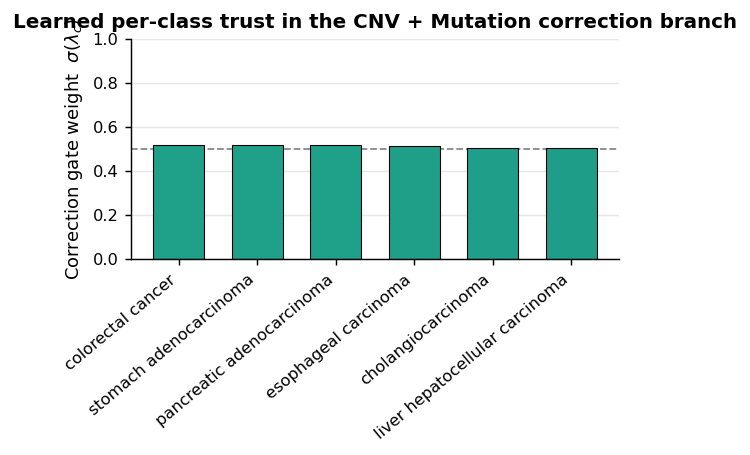

In [8]:
section('RESULT 1/2: PrimaryCorrectionNet accuracy, 3 seeds')

main_model_fn = lambda: PrimaryCorrectionNet(CONFIG['gene_counts'], CONFIG['embed_dim'],
                                              CONFIG['hidden_dim'], num_classes, CONFIG['dropout'])

main_summary = run_multi_seed(main_model_fn, CONFIG['seeds'], train_loader, val_loader, test_loader,
                               cw_tensor, CONFIG['main_epochs'], CONFIG['main_patience'],
                               tag='PrimaryCorrectionNet')

ref_run = main_summary['runs'][0]
print(f'\nLearned per-class correction gate (sigmoid(lambda), seed={CONFIG["seeds"][0]}):')
for c, l in sorted(zip(le.classes_, ref_run['lambda']), key=lambda x: -x[1]):
    print(f'  {c:<35} {l:.3f}')
print('\n(near 0 = model learned to ignore CNV/Mutation for that class; near 1 = fully trusts')
print('the correction branch there. Read this before writing it up: it is only informative if')
print('it varies meaningfully across classes -- if every class lands near the same value, the')
print('gate did not learn anything class-specific.)')

fig, ax = plt.subplots(figsize=(4.6, 3.6))
order_i = np.argsort(-ref_run['lambda'])
bar_colors = [VIRIDIS(0.15 + 0.80 * v) for v in ref_run['lambda'][order_i]]  # color encodes magnitude, same as height
ax.bar(range(num_classes), ref_run['lambda'][order_i], color=bar_colors, edgecolor='black', linewidth=0.6, width=0.65)
ax.axhline(0.5, color=BASELINE_GREY, linestyle='--', linewidth=1, zorder=0)
ax.set_xticks(range(num_classes))
ax.set_xticklabels([le.classes_[i] for i in order_i], rotation=40, ha='right')
ax.set_ylabel('Correction gate weight  ' + r'$\sigma(\lambda_c)$')
ax.set_ylim(0, 1)
ax.set_title('Learned per-class trust in the CNV + Mutation correction branch')
fig.tight_layout()
save_fig(fig, 'gibridge_lambda_weights', CONFIG['checkpoint_dir'])
plt.show()


  Confusion matrix + per-class report (seed=42)


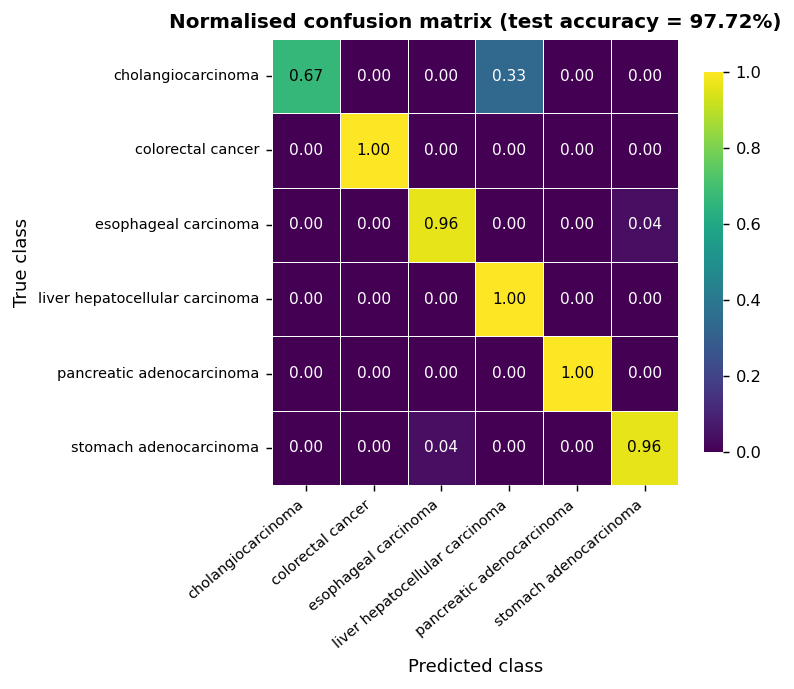

                                precision    recall  f1-score   support

            cholangiocarcinoma      1.000     0.667     0.800         6
             colorectal cancer      1.000     1.000     1.000        53
          esophageal carcinoma      0.929     0.963     0.945        27
liver hepatocellular carcinoma      0.964     1.000     0.981        53
     pancreatic adenocarcinoma      1.000     1.000     1.000        25
        stomach adenocarcinoma      0.981     0.964     0.972        55

                      accuracy                          0.977       219
                     macro avg      0.979     0.932     0.950       219
                  weighted avg      0.978     0.977     0.976       219



In [9]:
section('Confusion matrix + per-class report (seed=%d)' % CONFIG['seeds'][0])

cm = confusion_matrix(ref_run['labels'], ref_run['preds'])
cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, ax = plt.subplots(figsize=(6.2, 5.4))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='viridis', xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5, linecolor='white', annot_kws={'size': 8.5}, cbar_kws={'shrink': 0.85})
# viridis runs dark-purple -> yellow; a single annotation color would be unreadable at one
# end, so set each cell's text color from its own value instead of a fixed choice.
for text, value in zip(ax.texts, cm_norm.flatten()):
    text.set_color('black' if value > 0.6 else 'white')
ax.set_title(f'Normalised confusion matrix (test accuracy = {ref_run["test_acc"]:.2f}%)')
ax.set_xlabel('Predicted class'); ax.set_ylabel('True class')
ax.tick_params(axis='x', rotation=40, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
for lbl in ax.get_xticklabels():
    lbl.set_ha('right')
fig.tight_layout()
save_fig(fig, 'gibridge_confusion_matrix', CONFIG['checkpoint_dir'])
plt.show()

print(classification_report(ref_run['labels'], ref_run['preds'], target_names=le.classes_, digits=3))


  COMPARISON TABLE + FIGURE -- for the manuscript results section
Table A -- internal comparison (identical split, identical selected features)

                         Method            Type   Accuracy      Macro-F1           MCC
            Logistic Regression    Classical ML      95.89        0.9167        0.9481
                  Random Forest    Classical ML      93.61        0.9096        0.9214
                   SVM (linear)    Classical ML      96.35        0.9214        0.9539
                        XGBoost    Classical ML      97.26        0.9599        0.9653
                 mRNA-only (LR) Single-modality      95.43        0.9123        0.9423
PrimaryCorrectionNet (proposed)     Deep (ours) 97.11±0.57 0.9347±0.0108 0.9635±0.0072


Table B -- published methods, CONTEXT ONLY (different cohorts/classes/modalities)

                                     Method        Modalities                         Task Accuracy
                 MOGONET (Wang et al. 2021) mRNA+methyl+miRN

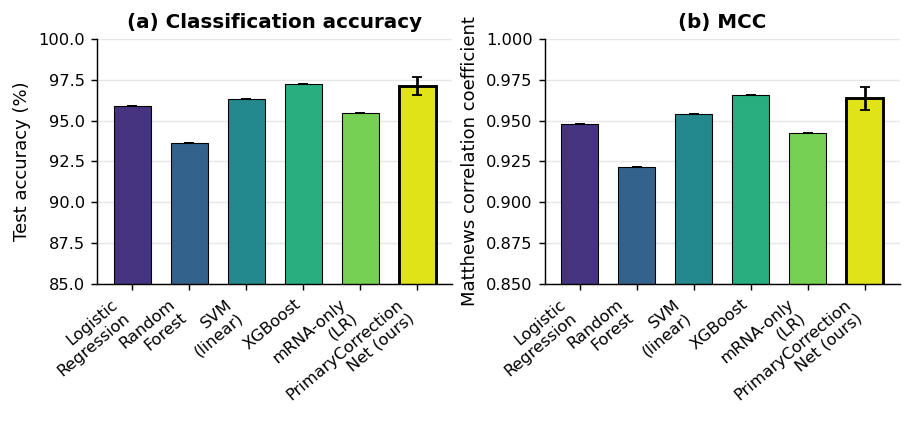

In [10]:
section('COMPARISON TABLE + FIGURE -- for the manuscript results section')

rows_internal = []
for name, r in baseline_results.items():
    rows_internal.append({'Method': name, 'Type': 'Classical ML',
                           'Accuracy': f'{r["acc"]:.2f}', 'Macro-F1': f'{r["macro_f1"]:.4f}',
                           'MCC': f'{r["mcc"]:.4f}'})
mr = modality_alone_results['mrna']
rows_internal.append({'Method': 'mRNA-only (LR)', 'Type': 'Single-modality',
                       'Accuracy': f'{mr["acc"]:.2f}', 'Macro-F1': f'{mr["macro_f1"]:.4f}', 'MCC': f'{mr["mcc"]:.4f}'})
rows_internal.append({'Method': 'PrimaryCorrectionNet (proposed)', 'Type': 'Deep (ours)',
    'Accuracy': f'{main_summary["test_acc_mean"]:.2f}\u00b1{main_summary["test_acc_std"]:.2f}',
    'Macro-F1': f'{main_summary["macro_f1_mean"]:.4f}\u00b1{main_summary["macro_f1_std"]:.4f}',
    'MCC': f'{main_summary["mcc_mean"]:.4f}\u00b1{main_summary["mcc_std"]:.4f}'})

df_internal = pd.DataFrame(rows_internal)
print('Table A -- internal comparison (identical split, identical selected features)\n')
print(df_internal.to_string(index=False))

rows_published = [
    {'Method': 'MOGONET (Wang et al. 2021)', 'Modalities': 'mRNA+methyl+miRNA',
     'Task': '5-class (BRCA subtype)', 'Accuracy': '82.9%'},
    {'Method': 'MoGCN', 'Modalities': 'mRNA+CNV+RPPA', 'Task': '3-class (pan-kidney subtype)', 'Accuracy': '97.71%'},
    {'Method': 'MoXGATE', 'Modalities': 'mRNA+methyl+miRNA', 'Task': '5-class (subtype)', 'Accuracy': '95.0%'},
    {'Method': 'LASSO-MOGAT (Alharbi 2024)', 'Modalities': 'mRNA+miRNA+methyl',
     'Task': '32-class (pan-cancer+normal)', 'Accuracy': '94.68%'},
    {'Method': 'OncoBridge-CMT (parent framework, same lab)', 'Modalities': 'mRNA+CNV+Mut+Meth',
     'Task': '22-class (pan-cancer)', 'Accuracy': '95.74%'},
]
df_published = pd.DataFrame(rows_published)
print('\n\nTable B -- published methods, CONTEXT ONLY (different cohorts/classes/modalities)\n')
print(df_published.to_string(index=False))

def df_to_markdown(df):
    cols = df.columns.tolist()
    lines = ['| ' + ' | '.join(cols) + ' |', '|' + '|'.join(['---'] * len(cols)) + '|']
    for _, row in df.iterrows():
        lines.append('| ' + ' | '.join(str(row[c]) for c in cols) + ' |')
    return '\n'.join(lines)

print('\n\n' + '=' * 70)
print('  MARKDOWN -- copy directly into the manuscript')
print('=' * 70)
print('\n**Table A. Internal comparison.**\n')
print(df_to_markdown(df_internal))
print('\n**Table B. Published methods, context only.**\n')
print(df_to_markdown(df_published))

df_internal.to_csv(f'{CONFIG["checkpoint_dir"]}gibridge_comparison_internal.csv', index=False)
df_published.to_csv(f'{CONFIG["checkpoint_dir"]}gibridge_comparison_published.csv', index=False)
print('\n\nSaved: gibridge_comparison_internal.csv, gibridge_comparison_published.csv')

# -- comparison figure: accuracy + MCC, side by side, all bars from the same viridis --
# ramp so the figure matches every other figure in this notebook and in OncoBridge.
labels = ['Logistic\nRegression', 'Random\nForest', 'SVM\n(linear)']
accs   = [baseline_results['Logistic Regression']['acc'], baseline_results['Random Forest']['acc'],
          baseline_results['SVM (linear)']['acc']]
mccs   = [baseline_results['Logistic Regression']['mcc'], baseline_results['Random Forest']['mcc'],
          baseline_results['SVM (linear)']['mcc']]
errs   = [0, 0, 0]
if HAS_XGB:
    labels.append('XGBoost'); accs.append(baseline_results['XGBoost']['acc'])
    mccs.append(baseline_results['XGBoost']['mcc']); errs.append(0)
labels.append('mRNA-only\n(LR)'); accs.append(mr['acc']); mccs.append(mr['mcc']); errs.append(0)
labels.append('PrimaryCorrection\nNet (ours)'); accs.append(main_summary['test_acc_mean'])
mccs.append(main_summary['mcc_mean']); errs.append(main_summary['test_acc_std'])
mcc_errs = errs[:-1] + [main_summary['mcc_std']]

bar_colors = viridis_colors(len(labels))
edge_widths = [0.6] * (len(labels) - 1) + [1.6]   # thicker border highlights the proposed model

fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL[0], DOUBLE_COL[1]))
axes[0].bar(labels, accs, yerr=errs, color=bar_colors, edgecolor='black', linewidth=edge_widths, capsize=3, width=0.65)
axes[0].set_ylabel('Test accuracy (%)'); axes[0].set_ylim(85, 100)
axes[0].set_title('(a) Classification accuracy')
axes[0].tick_params(axis='x', rotation=40)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha('right')

axes[1].bar(labels, mccs, yerr=mcc_errs, color=bar_colors, edgecolor='black', linewidth=edge_widths, capsize=3, width=0.65)
axes[1].set_ylabel('Matthews correlation coefficient'); axes[1].set_ylim(0.85, 1.0)
axes[1].set_title('(b) MCC')
axes[1].tick_params(axis='x', rotation=40)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha('right')

fig.tight_layout()
save_fig(fig, 'gibridge_comparison_barplot', CONFIG['checkpoint_dir'])
plt.show()

In [11]:
section('Save artifacts')

for i, s in enumerate(CONFIG['seeds']):
    torch.save(main_summary['runs'][i]['state_dict'], f'{CONFIG["checkpoint_dir"]}gibridge_seed{s}.pt')
best_i = int(np.argmax([r['test_acc'] for r in main_summary['runs']]))
best_seed = CONFIG['seeds'][best_i]
import shutil
shutil.copy(f'{CONFIG["checkpoint_dir"]}gibridge_seed{best_seed}.pt', f'{CONFIG["checkpoint_dir"]}gibridge_best.pt')

joblib.dump(lr_clf, f'{CONFIG["checkpoint_dir"]}gibridge_lr_baseline.pkl')
if HAS_XGB:
    joblib.dump(xgb_clf, f'{CONFIG["checkpoint_dir"]}gibridge_xgb_baseline.pkl')

with open(f'{CONFIG["checkpoint_dir"]}gibridge_config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)

print(f'Saved: {len(CONFIG["seeds"])} NN checkpoints (best seed: {best_seed}), LR/XGBoost baselines,')
print('config JSON. (Gene JSONs, scalers, label classes already saved in cell 4.)')


  Save artifacts
Saved: 3 NN checkpoints (best seed: 42), LR/XGBoost baselines,
config JSON. (Gene JSONs, scalers, label classes already saved in cell 4.)



  Figure: GI cancer type sample counts table


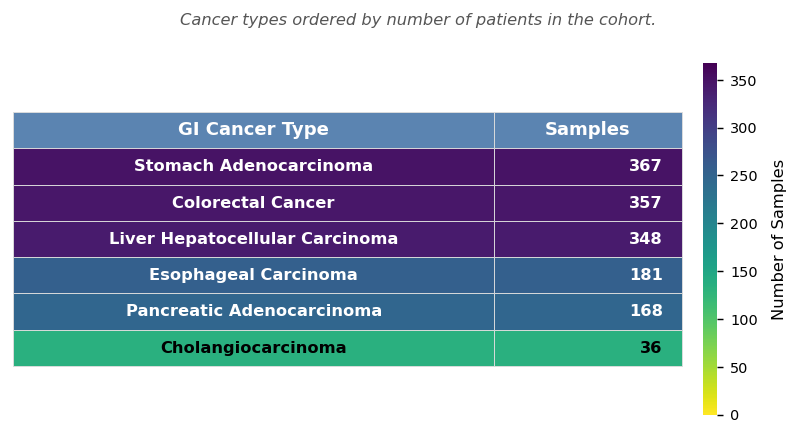

In [12]:
section('Figure: GI cancer type sample counts table')

class_counts_series = label_df[CONFIG['label_col']].value_counts()
table_data_counts = sorted(
    [(cname, int(n)) for cname, n in class_counts_series.items()],
    key=lambda x: x[1], reverse=True
)

cmap = plt.get_cmap('viridis_r')
max_n = max(n for _, n in table_data_counts)

HEADER_BG = '#5B84B1'
BORDER_GREY = '#DDDDDD'

def count_color(n):
    frac = np.sqrt(n / max_n)
    return cmap(0.10 + 0.85 * frac)

fig, ax = plt.subplots(figsize=(6.5, 0.34 * len(table_data_counts) + 1.1))
ax.axis('off')

cell_text = [[cname.title(), f'{n:,}'] for cname, n in table_data_counts]
cell_colors = [[count_color(n), count_color(n)] for _, n in table_data_counts]

tbl = ax.table(cellText=cell_text, cellColours=cell_colors,
                colLabels=['GI Cancer Type', 'Samples'],
                cellLoc='center', colLoc='center', loc='center',
                colWidths=[0.72, 0.28])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(BORDER_GREY)
    cell.set_linewidth(0.5)
    if r == 0:
        cell.set_facecolor(HEADER_BG)
        cell.set_text_props(color='white', fontweight='bold', fontsize=10)
        continue
    n_val = table_data_counts[r - 1][1]
    frac = np.sqrt(n_val / max_n)
    if frac > 0.55:
        cell.get_text().set_color('white')
    cell.set_text_props(fontweight='bold')
    if c == 1:
        cell.set_text_props(ha='right')

fig.text(0.5, 0.975, 'Cancer types ordered by number of patients in the cohort.',
         ha='center', fontsize=9, style='italic', color='#555555')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, max_n))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.05, pad=0.03, aspect=25)
cbar.set_label('Number of Samples', fontsize=9, labelpad=8)
cbar.ax.tick_params(labelsize=8)
cbar.outline.set_visible(False)

plt.subplots_adjust(top=0.88, bottom=0.02, left=0.02, right=0.88)
save_fig(fig, 'gibridge_fig_sample_counts_table', CONFIG['checkpoint_dir'])
plt.show()


  Figure: top gene attribution per GI cancer type (gradient x input, mRNA)
Attribution computed for 6/6 classes (classes with zero correct test predictions are skipped).


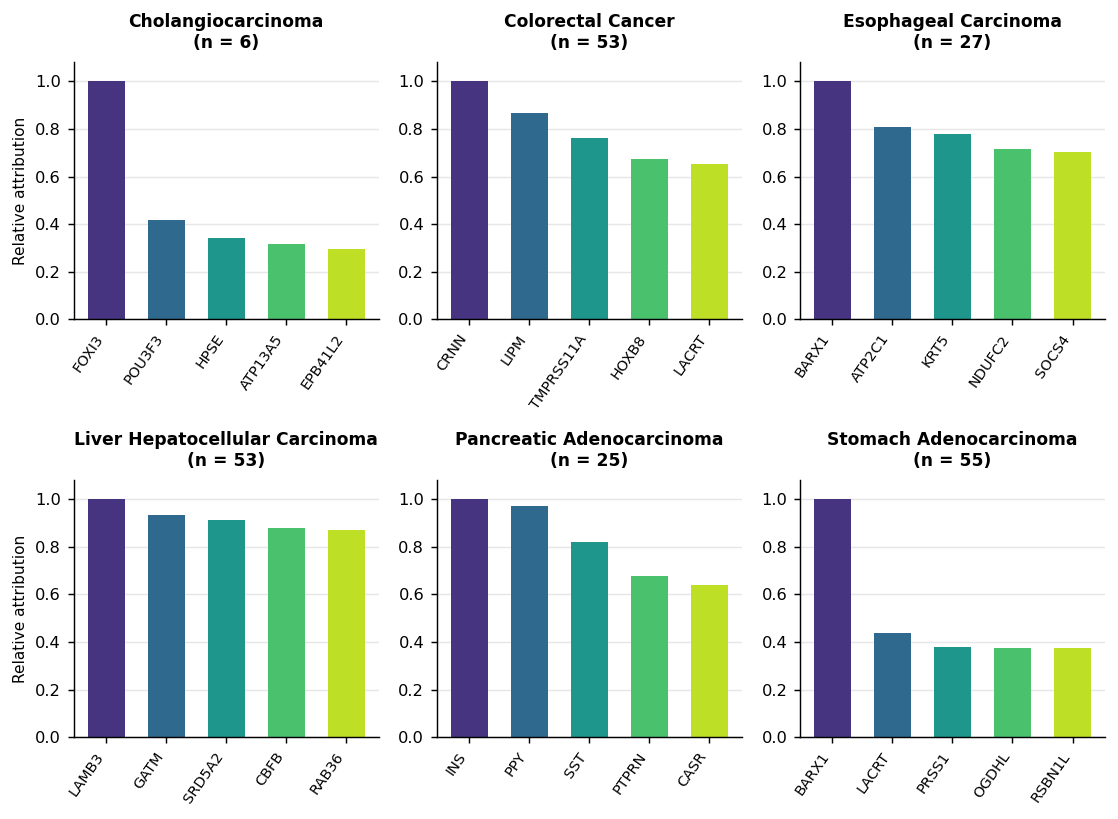

In [13]:
section('Figure: top gene attribution per GI cancer type (gradient x input, mRNA)')

KNOWN_ARTIFACT_GENES = {'KRT14', 'KRT16', 'KRT6A', 'KRT6C', 'KRT13', 'FGA', 'SFTPB', 'KLK3'}

import re
UNCHARACTERIZED_PATTERN = re.compile(
    r'^(LOC\d+|C\d+orf\d+|LINC\d+|MIR\d+\w*|SNOR\w*|RP\d+-\w+|'
    r'A[CL]\d{6}\.\d+|AP\d{6}\.\d+|CTD-\w+|CTA-\w+|CTB-\w+|RNU\d+\w*|'
    r'.*P\d*$|.*-AS\d+$|.*-DT$|.*-IT\d+$)',
    re.IGNORECASE
)
def is_characterized(gene_name):
    return not bool(UNCHARACTERIZED_PATTERN.match(gene_name))

# rebuild the seed=42 reference model purely for gradient attribution
attr_model = PrimaryCorrectionNet(CONFIG['gene_counts'], CONFIG['embed_dim'], CONFIG['hidden_dim'],
                                   num_classes, CONFIG['dropout']).to(DEVICE)
attr_model.load_state_dict(ref_run['state_dict'])
attr_model.eval()

mrna_te = torch.FloatTensor(Xp['mrna'][2]).to(DEVICE)
cnv_te  = torch.FloatTensor(Xp['cnv'][2]).to(DEVICE)
mut_te  = torch.FloatTensor(Xp['mut'][2]).to(DEVICE)
meth_te = torch.FloatTensor(Xp['meth'][2]).to(DEVICE)
labels_te = y_all[te_idx]

attr_sums = {c: None for c in range(num_classes)}
attr_counts = {c: 0 for c in range(num_classes)}

ATTR_BATCH_SIZE = 32
n_te = mrna_te.shape[0]
for start in range(0, n_te, ATTR_BATCH_SIZE):
    end = min(start + ATTR_BATCH_SIZE, n_te)
    mrna_g = mrna_te[start:end].clone().requires_grad_(True)
    cnv_b, mut_b, meth_b = cnv_te[start:end], mut_te[start:end], meth_te[start:end]
    labels_b = torch.LongTensor(labels_te[start:end]).to(DEVICE)

    logits = attr_model(mrna_g, cnv_b, mut_b, meth_b)
    true_logit = logits.gather(1, labels_b.unsqueeze(1)).squeeze(1)
    other_mean = (logits.sum(1) - true_logit) / (num_classes - 1)
    margin = true_logit - other_mean

    attr_model.zero_grad(set_to_none=True)
    margin.sum().backward()

    grad_attr = (mrna_g.grad * mrna_g).abs().detach().cpu().numpy()
    preds_np = logits.argmax(1).detach().cpu().numpy()
    labels_np = labels_b.cpu().numpy()

    for i in range(len(labels_np)):
        if preds_np[i] != labels_np[i]:
            continue
        c = int(labels_np[i])
        if attr_sums[c] is None:
            attr_sums[c] = grad_attr[i].copy()
        else:
            attr_sums[c] += grad_attr[i]
        attr_counts[c] += 1

mean_attr = {c: attr_sums[c] / attr_counts[c] for c in range(num_classes)
             if attr_counts[c] and attr_sums[c] is not None}

mean_attr_filtered = {}
for c, attr_vec in mean_attr.items():
    filtered = attr_vec.copy()
    for gene in KNOWN_ARTIFACT_GENES:
        if gene in selected_genes['mrna']:
            filtered[selected_genes['mrna'].index(gene)] = 0.0
    mean_attr_filtered[c] = filtered

print(f'Attribution computed for {len(mean_attr_filtered)}/{num_classes} classes '
      f'(classes with zero correct test predictions are skipped).')

TOP_N_GENES = 5
RANK_COLORS = [VIRIDIS(x) for x in np.linspace(0.15, 0.90, TOP_N_GENES)]

SHOWCASE_TYPES = list(le.classes_)   # all 6 GI classes -- small enough to show every one
n_cols = 3
n_rows = int(np.ceil(len(SHOWCASE_TYPES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.9 * n_cols, 3.2 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax_i, cname in enumerate(SHOWCASE_TYPES):
    c = list(le.classes_).index(cname)
    ax = axes[ax_i]
    if c not in mean_attr_filtered:
        ax.axis('off')
        ax.set_title(f'{cname.title()}\n(no correct test predictions)', fontsize=9)
        continue

    order = np.argsort(mean_attr_filtered[c])[::-1]
    top_genes, top_scores = [], []
    for idx in order:
        gene = selected_genes['mrna'][idx]
        if is_characterized(gene):
            top_genes.append(gene)
            top_scores.append(mean_attr_filtered[c][idx])
        if len(top_genes) == TOP_N_GENES:
            break
    top_scores = np.array(top_scores)
    norm_scores = top_scores / top_scores.max() if len(top_scores) and top_scores.max() > 0 else top_scores

    ax.bar(range(len(top_genes)), norm_scores, color=RANK_COLORS[:len(top_genes)], width=0.62)
    ax.set_xticks(range(len(top_genes)))
    ax.set_xticklabels(top_genes, rotation=55, ha='right', fontsize=8)

    n_samples = int(np.sum(labels_te == c))
    ax.set_title(f'{cname.title()}\n(n = {n_samples})', fontsize=9.5, fontweight='bold', pad=8)
    ax.set_ylim(0, 1.08)
    if ax_i % n_cols == 0:
        ax.set_ylabel('Relative attribution', fontsize=8.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax_i in range(len(SHOWCASE_TYPES), len(axes)):
    axes[ax_i].axis('off')

plt.tight_layout()
save_fig(fig, 'gibridge_fig_top5_genes_bar_viridis', CONFIG['checkpoint_dir'])
plt.show()


  Figure: confusion matrix + per-class precision/recall/F1 table


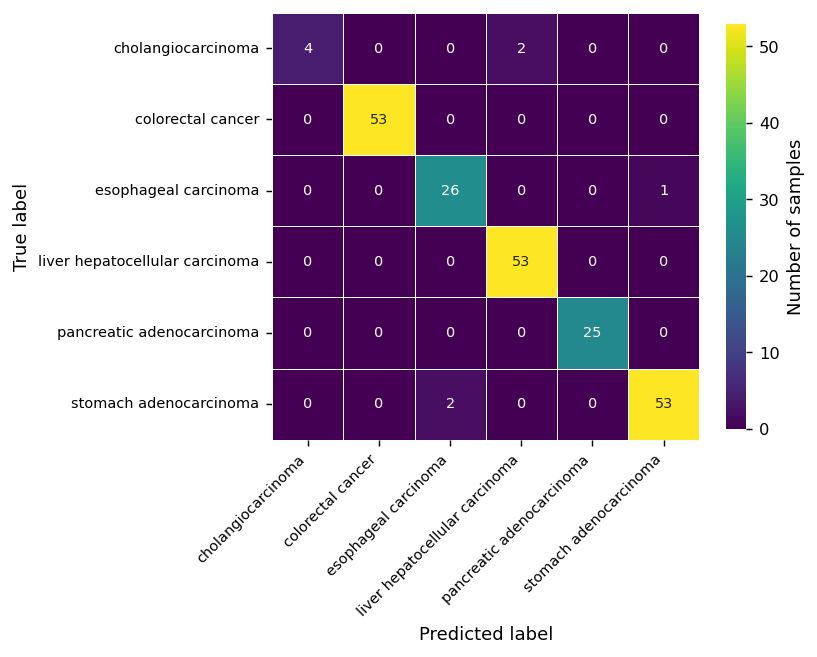

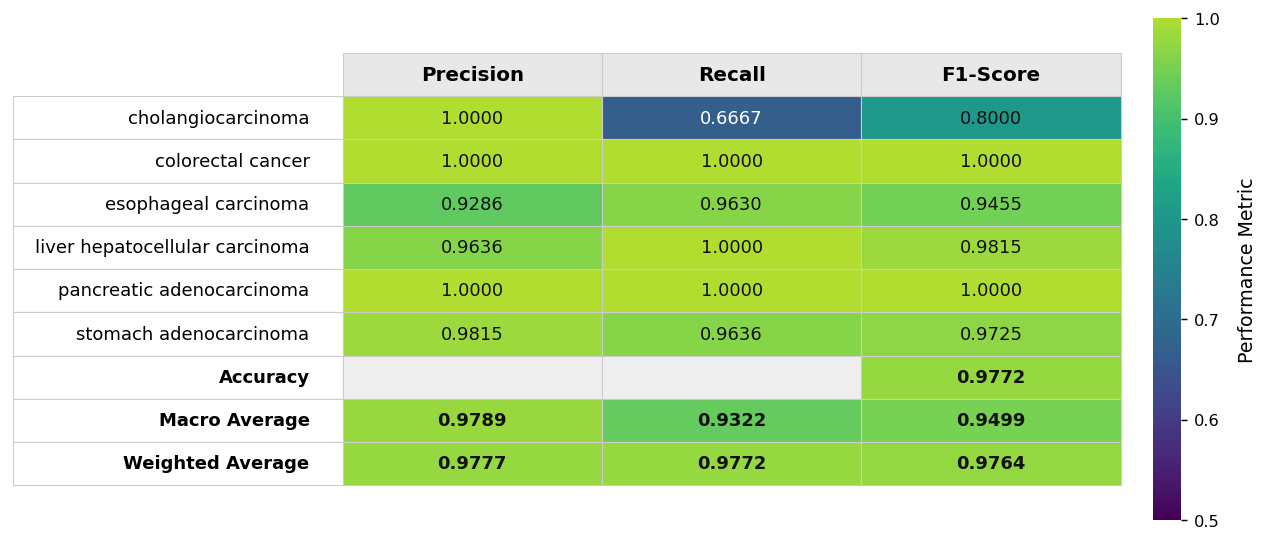

In [14]:
section('Figure: confusion matrix + per-class precision/recall/F1 table')

class_labels = list(le.classes_)
labels_arr = ref_run['labels']
preds_arr = ref_run['preds']
probs_arr = ref_run['probs']

CM_CMAP = 'viridis'
cm = confusion_matrix(labels_arr, preds_arr)
fig, ax = plt.subplots(figsize=(6.4, 6.0))
sns.heatmap(cm, cmap=CM_CMAP, annot=True, fmt='d', annot_kws={'size': 8},
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.3, linecolor='white', square=True,
            cbar_kws={'label': 'Number of samples', 'shrink': 0.7}, ax=ax)
ax.set_xlabel('Predicted label', fontsize=10)
ax.set_ylabel('True label', fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
save_fig(fig, 'gibridge_fig_confusion_matrix', CONFIG['checkpoint_dir'])
plt.show()
pd.DataFrame(cm, index=class_labels, columns=class_labels).to_csv(
    f'{CONFIG["checkpoint_dir"]}gibridge_fig_confusion_matrix.csv')

from sklearn.metrics import classification_report, precision_recall_fscore_support
import matplotlib.colors as mcolors

precision, recall, f1, support = precision_recall_fscore_support(
    labels_arr, preds_arr, labels=range(num_classes), zero_division=0)
overall_acc = (preds_arr == labels_arr).mean()
report = classification_report(labels_arr, preds_arr, labels=range(num_classes),
                                target_names=class_labels, output_dict=True, zero_division=0)
macro = report['macro avg']
weighted = report['weighted avg']

table_rows = class_labels + ['Accuracy', 'Macro Average', 'Weighted Average']
col_labels = ['Precision', 'Recall', 'F1-Score']

table_data = np.full((len(table_rows), 3), np.nan)
table_data[:num_classes, 0] = precision
table_data[:num_classes, 1] = recall
table_data[:num_classes, 2] = f1
table_data[num_classes]     = [np.nan, np.nan, overall_acc]
table_data[num_classes + 1] = [macro['precision'], macro['recall'], macro['f1-score']]
table_data[num_classes + 2] = [weighted['precision'], weighted['recall'], weighted['f1-score']]

_viridis_full = plt.get_cmap('viridis')
score_cmap = mcolors.LinearSegmentedColormap.from_list(
    'viridis_trunc', _viridis_full(np.linspace(0.0, 0.88, 256)))
vmin, vmax = 0.5, 1.0

def score_color(val):
    if val is None or np.isnan(val):
        return '#EEEEEE'
    return score_cmap((np.clip(val, vmin, vmax) - vmin) / (vmax - vmin))

cell_text = [[f'{v:.4f}' if not np.isnan(v) else '' for v in row] for row in table_data]
cell_colors = [[score_color(v) for v in row] for row in table_data]

fig, ax_tab = plt.subplots(figsize=(7.0, 0.42 * len(class_labels) + 1.5))
ax_tab.axis('off')

tbl = ax_tab.table(cellText=cell_text, cellColours=cell_colors,
                    rowLabels=table_rows, colLabels=col_labels,
                    cellLoc='center', rowLoc='right', loc='center',
                    colWidths=[0.28, 0.28, 0.28])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.6)

HEADER_BG = '#E8E8E8'
BORDER_GREY = '#CCCCCC'

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(BORDER_GREY)
    cell.set_linewidth(0.6)
    if r == 0:
        cell.set_text_props(fontweight='bold', fontsize=11)
        cell.set_facecolor(HEADER_BG)
        continue
    row_idx = r - 1
    is_summary = row_idx >= num_classes
    if is_summary:
        cell.get_text().set_fontweight('bold')
    if c == -1:
        cell.set_facecolor('white')
        cell.set_text_props(fontsize=10)
        continue
    val = table_data[row_idx, c]
    if not np.isnan(val):
        norm_val = (np.clip(val, vmin, vmax) - vmin) / (vmax - vmin)
        cell.get_text().set_color('white' if norm_val < 0.42 else '#111111')

sm = plt.cm.ScalarMappable(cmap=score_cmap, norm=plt.Normalize(vmin, vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_tab, fraction=0.05, pad=0.08, aspect=18)
cbar.set_label('Performance Metric', fontsize=10.5, labelpad=10)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_visible(False)

plt.subplots_adjust(top=0.98, bottom=0.02, left=0.02, right=0.92)
save_fig(fig, 'gibridge_fig_score_table', CONFIG['checkpoint_dir'])
plt.show()

pd.DataFrame(table_data, index=table_rows, columns=col_labels).to_csv(
    f'{CONFIG["checkpoint_dir"]}gibridge_fig_score_table.csv')


  Figure: ROC and Precision-Recall curves (per-class + micro/macro/weighted average)


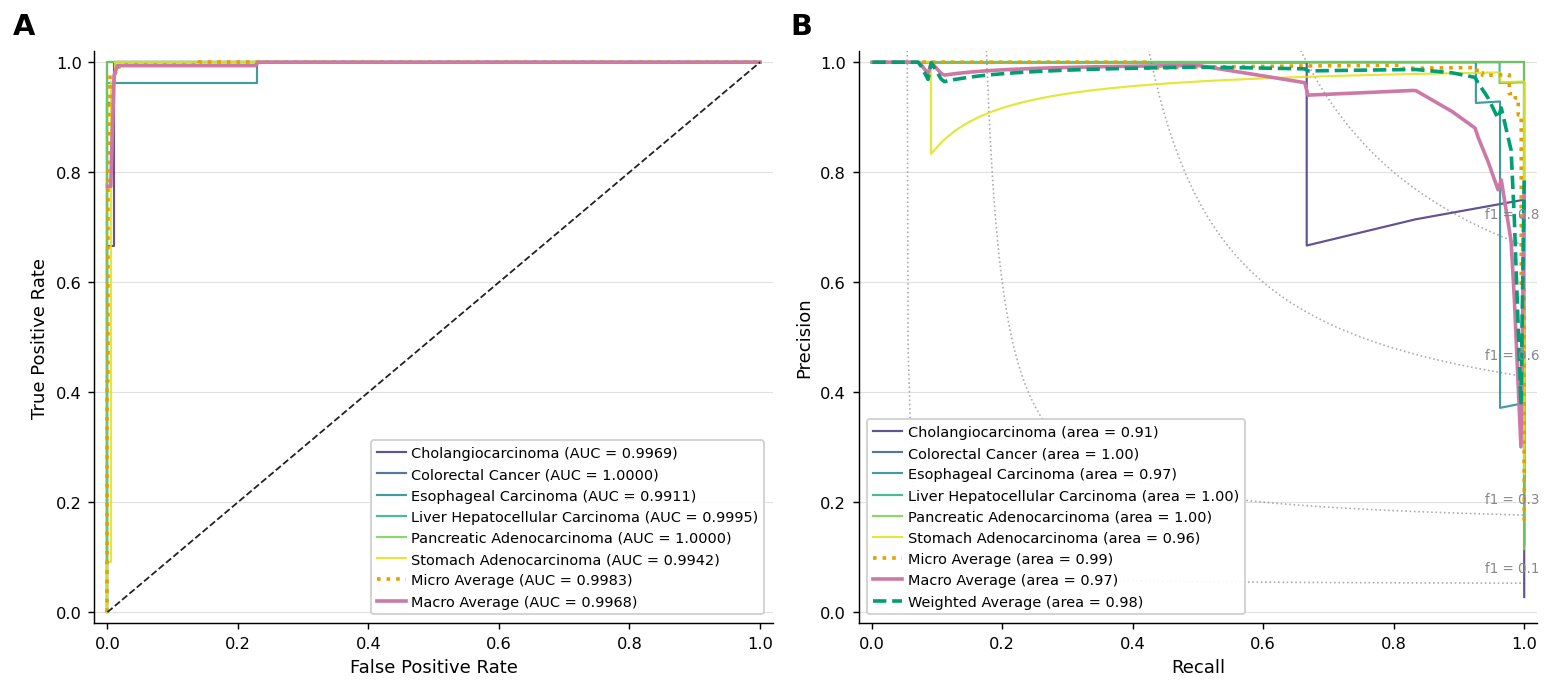

In [15]:
section('Figure: ROC and Precision-Recall curves (per-class + micro/macro/weighted average)')

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def light_hgrid(ax):
    ax.grid(axis='y', color=BASELINE_GREY, alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

y_true_bin = np.zeros_like(probs_arr)
y_true_bin[np.arange(len(labels_arr)), labels_arr] = 1
support = y_true_bin.sum(axis=0)

CLASS_COLORS = {cls: c for cls, c in zip(le.classes_, viridis_colors(num_classes))}
MICRO_COLOR, MACRO_COLOR, WEIGHTED_COLOR = '#E69F00', '#CC79A7', '#009E73'
INK = '#222222'

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))

# ================================ Panel A: ROC ==============================
fpr_grid = np.linspace(0, 1, 200)
tprs_interp = []
for c, cname in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_true_bin[:, c], probs_arr[:, c])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=CLASS_COLORS[le.classes_[c]], linewidth=1.2, alpha=0.85,
                 label=f'{cname.title()} (AUC = {roc_auc:.4f})')
    tprs_interp.append(np.interp(fpr_grid, fpr, tpr))

micro_fpr, micro_tpr, _ = roc_curve(y_true_bin.ravel(), probs_arr.ravel())
micro_auc = auc(micro_fpr, micro_tpr)
axes[0].plot(micro_fpr, micro_tpr, color=MICRO_COLOR, linestyle=':', linewidth=2.0,
             label=f'Micro Average (AUC = {micro_auc:.4f})')

macro_tpr = np.mean(tprs_interp, axis=0)
macro_auc = auc(fpr_grid, macro_tpr)
axes[0].plot(fpr_grid, macro_tpr, color=MACRO_COLOR, linestyle='-', linewidth=2.0,
             label=f'Macro Average (AUC = {macro_auc:.4f})')

axes[0].plot([0, 1], [0, 1], color=INK, linestyle='--', linewidth=1.0)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)
axes[0].text(-0.12, 1.03, 'A', transform=axes[0].transAxes, fontsize=16, fontweight='bold')
light_hgrid(axes[0])

# ============================ Panel B: Precision-Recall ======================
recall_grid = np.linspace(0.001, 1, 200)

for f_score in (0.1, 0.3, 0.6, 0.8):
    x = np.linspace(f_score / 2 + 1e-3, 1, 200)
    y = f_score * x / (2 * x - f_score)
    axes[1].plot(x, y, color=BASELINE_GREY, linestyle=':', linewidth=0.9, alpha=0.7)
    axes[1].annotate(f'f1 = {f_score:.1f}', xy=(0.94, y[np.argmin(np.abs(x - 0.94))] + 0.02),
                      fontsize=7.5, color=BASELINE_GREY)

precisions_interp = []
ap_scores = []
for c, cname in enumerate(class_labels):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, c], probs_arr[:, c])
    ap = average_precision_score(y_true_bin[:, c], probs_arr[:, c])
    ap_scores.append(ap)
    axes[1].plot(rec, prec, color=CLASS_COLORS[le.classes_[c]], linewidth=1.2, alpha=0.85,
                 label=f'{cname.title()} (area = {ap:.2f})')
    order = np.argsort(rec)
    precisions_interp.append(np.interp(recall_grid, rec[order], prec[order]))

micro_prec, micro_rec, _ = precision_recall_curve(y_true_bin.ravel(), probs_arr.ravel())
micro_ap = average_precision_score(y_true_bin, probs_arr, average='micro')
axes[1].plot(micro_rec, micro_prec, color=MICRO_COLOR, linestyle=':', linewidth=2.0,
             label=f'Micro Average (area = {micro_ap:.2f})')

macro_prec = np.mean(precisions_interp, axis=0)
macro_ap = np.mean(ap_scores)
axes[1].plot(recall_grid, macro_prec, color=MACRO_COLOR, linestyle='-', linewidth=2.0,
             label=f'Macro Average (area = {macro_ap:.2f})')

weights = support / support.sum()
weighted_prec = np.average(precisions_interp, axis=0, weights=weights)
weighted_ap = np.average(ap_scores, weights=weights)
axes[1].plot(recall_grid, weighted_prec, color=WEIGHTED_COLOR, linestyle='--', linewidth=2.0,
             label=f'Weighted Average (area = {weighted_ap:.2f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)
axes[1].text(-0.1, 1.03, 'B', transform=axes[1].transAxes, fontsize=16, fontweight='bold')
light_hgrid(axes[1])

# both legends now sit INSIDE their own axes, in the corner the curves leave empty --
# no off-canvas bbox_to_anchor, so tight_layout can no longer squeeze them onto the data
axes[0].legend(loc='lower right', fontsize=8, framealpha=0.92, handletextpad=0.4, borderaxespad=0.6)
axes[1].legend(loc='lower left', fontsize=8, framealpha=0.92, handletextpad=0.4, borderaxespad=0.6)

plt.tight_layout()
save_fig(fig, 'gibridge_fig_roc_pr_curves', CONFIG['checkpoint_dir'])
plt.show()

[](http://)